## Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

#### 1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.shape

(12684, 26)

#### 2. Investigate the dataset for missing or problematic data.

In [4]:
data.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

From the above result, I noticed out of the 12684 records, only a handful of records do not have the **Bar**, **CoffeeHouse**, **CarryAway**, **RestaurantLessThan20** or **Restaurant20To50** fields populated. Hence, I decided to drop these records. However, a majority of the records do not have the **car** field populated. Hence, for this field, I decided to fill it with 'Unknown' value Both the **fillna** on car and **dropna** on other fields is done below.

#### 3. Decide what to do about your missing data -- drop, replace, other...

In [5]:
data['car'] = data['car'].fillna('Unknown')
data = data.dropna(subset=['CarryAway','Bar','CoffeeHouse','RestaurantLessThan20','Restaurant20To50'])
data.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
car                     0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

As you can see above, after doing the fillna and dropna, we no longer have any null values in any fields. The dataset is now good to use for analysis.

#### 4. What proportion of the total observations chose to accept the coupon?



In [6]:
coupon_acceptance_rate = data['Y'].mean()
print("Coupon Acceptance Rate:", coupon_acceptance_rate.round(4))

Coupon Acceptance Rate: 0.5693


I used the **mean()** function on the 'Y' field to calculate the overall coupon acceptance rate for the entire dataset, which is around **57%** .

#### 5. Use a bar plot to visualize the `coupon` column.

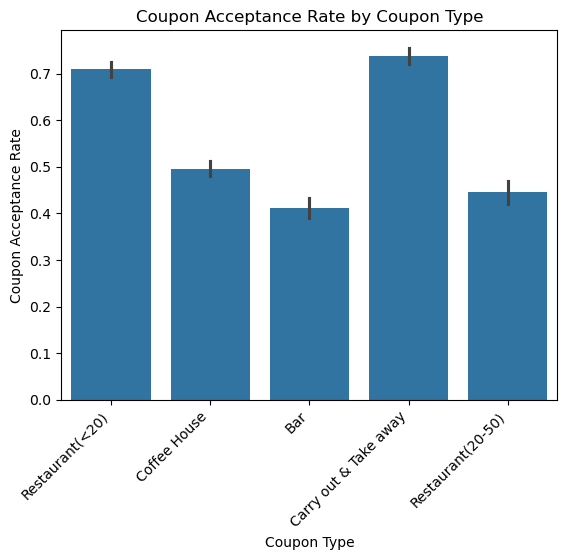

In [7]:
sns.barplot(data=data, x='coupon', y='Y')
plt.xlabel('Coupon Type')
plt.ylabel('Coupon Acceptance Rate')
plt.xticks(rotation=45, ha='right')
plt.title('Coupon Acceptance Rate by Coupon Type')
plt.show()

The above plot provides the acceptance rate for each type of coupon. We observe that the coupons for the **carry out and take away** and for **cheap restaurants** are the most popular, with the rates close to **70%**. The **Bar** coupons are the least accepted, around **40%** of the times.

#### 6. Use a histogram to visualize the temperature column.

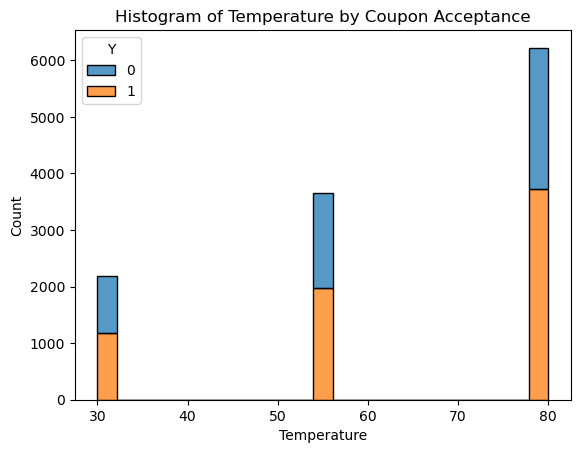

In [8]:
sns.histplot(data=data, x='temperature', hue='Y', multiple='stack')
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.title('Histogram of Temperature by Coupon Acceptance')
plt.show()

The histogram for the Temperature field above indicates that the coupons have a higher acceptance rate when the temperatures are higher.

#### 7. Bar plot of Coupon Acceptance by Time of Day for each Coupon type

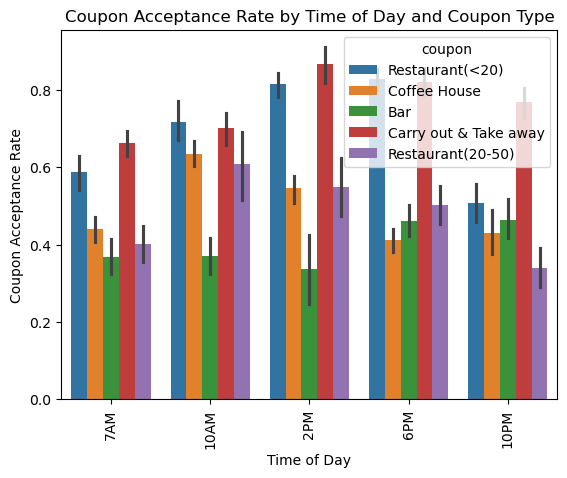

In [9]:
sns.barplot(data=data, x='time', y='Y', hue='coupon', order=['7AM', '10AM', '2PM', '6PM', '10PM'])
plt.xlabel('Time of Day')
plt.ylabel('Coupon Acceptance Rate')
plt.xticks(rotation=90)
plt.title('Coupon Acceptance Rate by Time of Day and Coupon Type')
plt.show()

I plotted a bar graph of the coupon acceptance for time of day (ordered cronologically from the morning to night), and used hue to show the rates by coupon type. The results are quite interesting, but kind of expected: The coupon acceptance rates are higher during office hours for the **Restaurant**, **Coffee house** and **Carry out** types. However, the **Bar** coupon acceptance tends to be higher in the off-business hours. 

#### 8. Bar plot of Coupon Acceptance by Age groups for each Coupon type

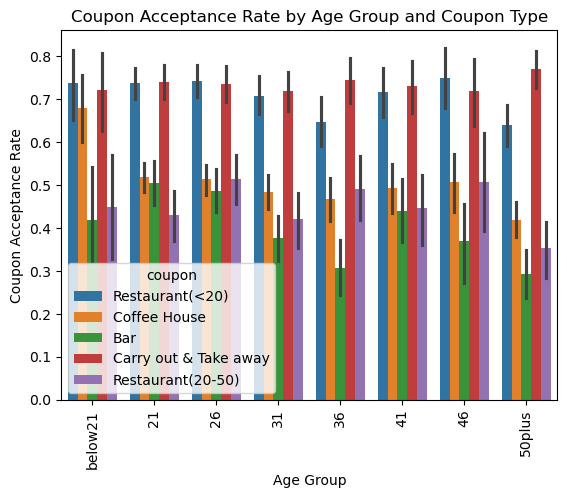

In [10]:
sns.barplot(data=data, x='age', y='Y', hue='coupon', order=['below21', '21', '26', '31', '36', '41', '46', '50plus'])
plt.xlabel('Age Group')
plt.ylabel('Coupon Acceptance Rate')
plt.xticks(rotation=90)
plt.title('Coupon Acceptance Rate by Age Group and Coupon Type')
plt.show()

Similar to the previous one, I plotted a bar graph of the coupon acceptance for each age group (ordered from younger to older groups). The results indicate that :
(a) The Carry out and cheap restaurant coupons are independent on the age of the driver. 
(b) The coffee house coupons are more popular among the younger age groups. 
(c) The expensive restaurant coupons are more popular among the older groups. 
(d) All the above trends are expected. However, one peculiar trend that can be observed is that the Bar coupons are popular among people in their 20s and 40s, but not in the 30s, where we see a sharp decline in the acceptance. If I have to explain this trend, I'd say that people in their 20s are mostly single, while 30s may consist more of married people.

#### 9. Bar plots of the Acceptance Rate by Gender and by people with or without children

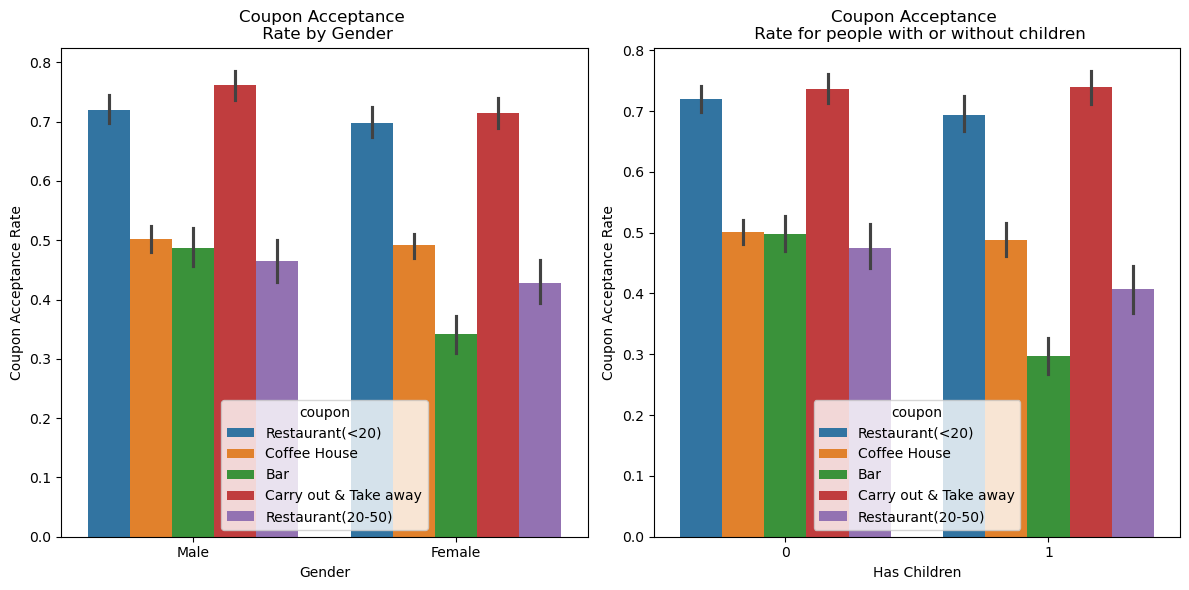

In [135]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))


order = ['never', 'less1', '1~3', '4~8', 'gt8']

sns.barplot(data=data, x='gender', y='Y', hue='coupon', ax=axes[0])
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Coupon Acceptance Rate')
axes[0].set_title('Coupon Acceptance \n Rate by Gender')

sns.barplot(data=data, x='has_children', y='Y', hue='coupon', ax=axes[1])
axes[1].set_xlabel('Has Children')
axes[1].set_ylabel('Coupon Acceptance Rate')
axes[1].set_title('Coupon Acceptance \n Rate for people with or without children')

plt.tight_layout() # Improves spacing between plots
plt.show()

I tried bar plots for other fields. Some of the parameters were found to not have much effect on the coupon acceptance rates. For example, the above plots show that the gender and whether the driver has kids or not, have little to no effect on the acceptance rates of most of the coupons. The only coupon that seems to have some correlation with these paramters is the Bar coupon, which has higher rates for Men than women, and also for people with no kids.

#### 10. Plots of the coupon acceptance rates of individual types of coupons against the number of times the driver visited the corresponding facility.

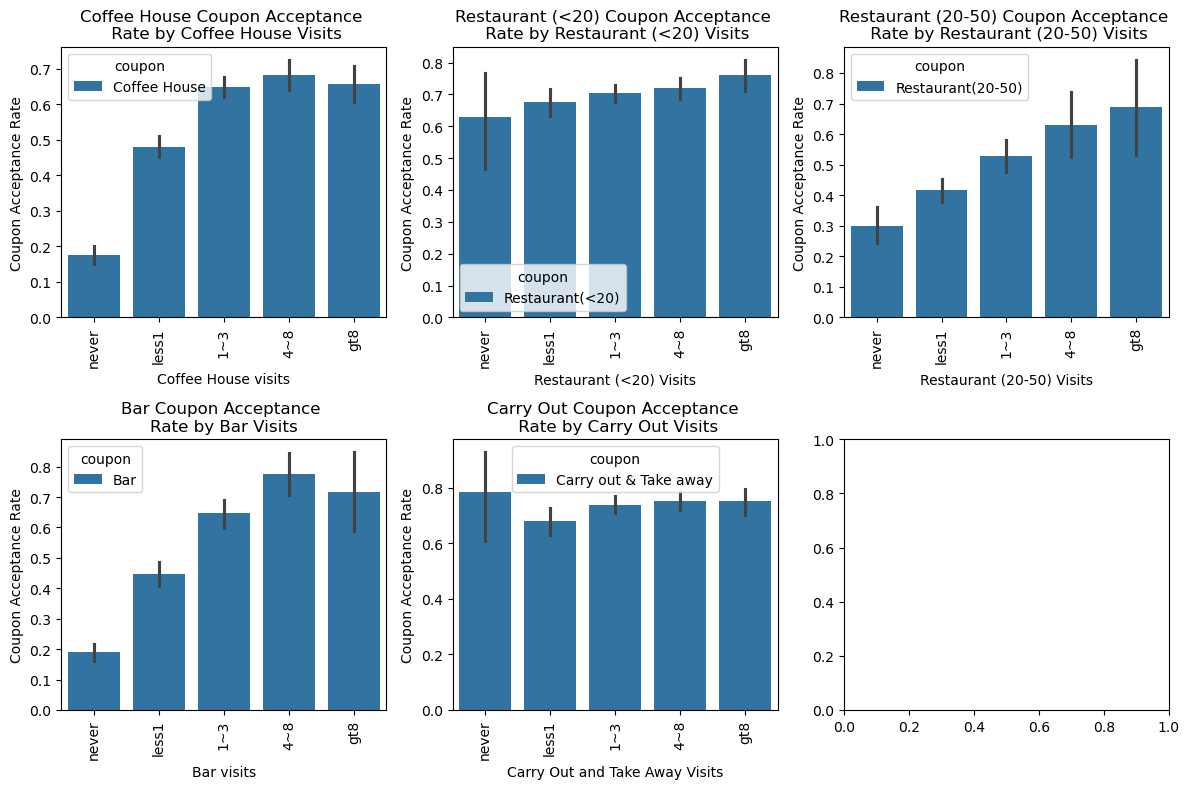

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))


order = ['never', 'less1', '1~3', '4~8', 'gt8']

sns.barplot(data=data[data['coupon'] == 'Coffee House'], x='CoffeeHouse', y='Y', hue='coupon', ax=axes[0, 0], order=order)
axes[0, 0].set_xlabel('Coffee House visits')
axes[0, 0].set_ylabel('Coupon Acceptance Rate')
axes[0, 0].xaxis.set_major_locator(plt.FixedLocator(range(len(order))))
axes[0, 0].xaxis.set_major_formatter(plt.FixedFormatter(order))
axes[0, 0].xaxis.set_tick_params(rotation=90)
axes[0, 0].set_title('Coffee House Coupon Acceptance \n Rate by Coffee House Visits')

sns.barplot(data=data[data['coupon'] == 'Restaurant(<20)'], x='RestaurantLessThan20', y='Y', hue='coupon', ax=axes[0,1], order=order)
axes[0, 1].set_xlabel('Restaurant (<20) Visits')
axes[0, 1].set_ylabel('Coupon Acceptance Rate')
axes[0, 1].xaxis.set_major_locator(plt.FixedLocator(range(len(order))))
axes[0, 1].xaxis.set_major_formatter(plt.FixedFormatter(order))
axes[0, 1].xaxis.set_tick_params(rotation=90)
axes[0, 1].set_title('Restaurant (<20) Coupon Acceptance \n Rate by Restaurant (<20) Visits')

sns.barplot(data=data[data['coupon'] == 'Restaurant(20-50)'], x='Restaurant20To50', y='Y', hue='coupon', ax=axes[0,2], order=order)
axes[0, 2].set_xlabel('Restaurant (20-50) Visits')
axes[0, 2].set_ylabel('Coupon Acceptance Rate')
axes[0, 2].xaxis.set_major_locator(plt.FixedLocator(range(len(order))))
axes[0, 2].xaxis.set_major_formatter(plt.FixedFormatter(order))
axes[0, 2].xaxis.set_tick_params(rotation=90)
axes[0, 2].set_title('Restaurant (20-50) Coupon Acceptance \n Rate by Restaurant (20-50) Visits')

sns.barplot(data=data[data['coupon'] == 'Bar'], x='Bar', y='Y', hue='coupon', ax=axes[1,0], order=order)
axes[1, 0].set_xlabel('Bar visits')
axes[1, 0].set_ylabel('Coupon Acceptance Rate')
axes[1, 0].xaxis.set_major_locator(plt.FixedLocator(range(len(order))))
axes[1, 0].xaxis.set_major_formatter(plt.FixedFormatter(order))
axes[1, 0].xaxis.set_tick_params(rotation=90)
axes[1, 0].set_title('Bar Coupon Acceptance \nRate by Bar Visits')

sns.barplot(data=data[data['coupon'] == 'Carry out & Take away'], x='CarryAway', y='Y', hue='coupon', ax=axes[1,1], order=order)
axes[1,1].set_xlabel('Carry Out and Take Away Visits')
axes[1,1].set_ylabel('Coupon Acceptance Rate')
axes[1,1].xaxis.set_major_locator(plt.FixedLocator(range(len(order))))
axes[1,1].xaxis.set_major_formatter(plt.FixedFormatter(order))
axes[1,1].xaxis.set_tick_params(rotation=90)
axes[1,1].set_title('Carry Out Coupon Acceptance \n Rate by Carry Out Visits')

plt.tight_layout() # Improves spacing between plots
plt.show()

I wanted to find out if the number of visits to the related facilities has an effect on the coupon acceptance rates of the related coupon type. E.g. Is a person that visits Bars frequently, more likely to accept a Bar type of coupon? The above sub-plots answer that question nicely. I have ordered the visits for each plot from never to most frequent. In case of Restaurants, Coffee Houses, and specially Bars, the graphs strongly suggest that a person that frequents these types of facilities is more likely to accept the coupon of that type. The ony coupon type that had no correlation with the frequent visits is the Carry out coupon, where regardless of the number of viists, a person is equally likely to accept the coupon. I found this analysis interesting and insightful.

### **Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

#### 1. Create a new `DataFrame` that contains just the bar coupons.


In [10]:
data_bar = data[data['coupon'] == 'Bar']

#### 2. What proportion of bar coupons were accepted?


In [172]:
bar_coupon_acceptance_rate = data_bar['Y'].mean()
print("Coupon Acceptance Rate for Bars:", bar_coupon_acceptance_rate.round(4))

Coupon Acceptance Rate for Bars: 0.4119


#### 3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [171]:
list_3_or_fewer_times = ['never', 'less1', '1~3']

acceptance_rate_3_or_fewer = data_bar[data_bar['Bar'].isin(list_3_or_fewer_times)]['Y'].mean()

acceptance_rate_4_or_more = data_bar[~data_bar['Bar'].isin(list_3_or_fewer_times)]['Y'].mean()

print("Coupon Acceptance Rate for those who visit the bar 3 or fewer times: ", acceptance_rate_3_or_fewer.round(4))
print("Coupon Acceptance Rate for those who visit the bar 4 or more times: ", acceptance_rate_4_or_more.round(4))


Coupon Acceptance Rate for those who visit the bar 3 or fewer times:  0.3727
Coupon Acceptance Rate for those who visit the bar 4 or more times:  0.7617


Observation: The acceptance rates for the bar coupon is much higher (76% vs 37%) among people who visit bars more than 4 times a month.

#### 4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [170]:
list_ages_above_25 = ['26', '31', '36', '41', '46', '50plus']
list_1_or_more_times = ['1~3', '4~8','gt8']

data_bar_age_above_25_1_or_more_times = data_bar[data_bar['age'].isin(list_ages_above_25) & data_bar['Bar'].isin(list_1_or_more_times)]
acceptance_rate_age_above_25_1_or_more_times = data_bar_age_above_25_1_or_more_times['Y'].mean()
acceptance_rate_all_others = data_bar[~data_bar.isin(data_bar_age_above_25_1_or_more_times)]['Y'].mean()

print("Coupon Acceptance Rate for drivers 25+ age who visit the bar 1 or more times: ", acceptance_rate_age_above_25_1_or_more_times.round(4))
print("Coupon Acceptance Rate for all others: ", acceptance_rate_all_others.round(4))

Coupon Acceptance Rate for drivers 25+ age who visit the bar 1 or more times:  0.6898
Coupon Acceptance Rate for all others:  0.3377


Observation: For drivers aged 25 or more, the coupon acceptance rate is much higher (69%) among those who visit the bar even once or more, than other people (34%)

#### 5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [169]:
acceptance_rate_adults_1_or_more_visits_not_farming = data_bar_age_above_25_1_or_more_times[~(data_bar_age_above_25_1_or_more_times['occupation'] == 'Farming Fishing & Forestry')]['Y'].mean()

print("Coupon Acceptance Rate for drivers 25+ age who visit the bar 1 or more times and occupation other than farming, fishing and forestry: ", acceptance_rate_adults_1_or_more_visits_not_farming.round(4))

Coupon Acceptance Rate for drivers 25+ age who visit the bar 1 or more times and occupation other than farming, fishing and forestry:  0.6898


Observation: The rate did not change by filtering out the people who are farmer, fisherman or in forestry. So, that occupation has no effect on the acceptance rate for adults visiting bars atleast once..

#### 6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [168]:
list_under_30 = ['below21','21','26']
list_more_than_4_times = ['4~8','gt8']
list_income_less_than_50K = ['Less than $12500','$12500 - $24999','$25000 - $37499','$37500 - $49999']

acceptance_rate_more_than_1_no_kid_not_widowed = data_bar[data_bar['Bar'].isin(list_1_or_more_times) & ~(data_bar['passanger'] == 'Kid(s)') & ~(data_bar['maritalStatus'] == 'Widowed')]['Y'].mean()

acceptance_rate_more_than_1_under_30 = data_bar[data_bar['Bar'].isin(list_1_or_more_times) & data_bar['age'].isin(list_under_30)]['Y'].mean()

acceptance_rate_cheap_restaurants_more_than_4_income_less_than_50K = data_bar[data_bar['RestaurantLessThan20'].isin(list_more_than_4_times) & data_bar['income'].isin(list_income_less_than_50K)]['Y'].mean()

print("Coupon Acceptance Rate for people who visit the bar 1 or more times and did not have kids as passengers and are not widowed: ", acceptance_rate_more_than_1_no_kid_not_widowed.round(4))
print("Coupon Acceptance Rate for people under 30 who visit the bar 1 or more times: ", acceptance_rate_more_than_1_under_30.round(4))
print("Coupon Acceptance Rate for people with income less than $50,000 who visit cheap restaurants 4 or more times: ", acceptance_rate_cheap_restaurants_more_than_4_income_less_than_50K.round(4))

Coupon Acceptance Rate for people who visit the bar 1 or more times and did not have kids as passengers and are not widowed:  0.7094
Coupon Acceptance Rate for people under 30 who visit the bar 1 or more times:  0.7195
Coupon Acceptance Rate for people with income less than $50,000 who visit cheap restaurants 4 or more times:  0.4565


#### 7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Based on the above observations, I can draw the following conclusions:

1. The overall acceptance rate for Bar type coupons (41%) is lower than the other types, like the Carry out coupons (70%).
2. The acceptance rate is higher among those who visit the bars frequently
3. It is also higher among adults who visit the bar at least once
4. It is higher among people who are not widowed and are not driving with a kid as a passenger.
5. It is only slightly higher (than average) among people who visit cheaper restaurants frequently, and are in the lower income groups.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

#### 1. Find out the proportion of coupon acceptance rate for expensive restaurants

In [167]:
data_expensive_restaunts = data[data['coupon'] == 'Restaurant(20-50)']
expensive_restaurant_coupon_acceptance_rate = data_expensive_restaunts['Y'].mean()
print("Coupon Acceptance Rate for expensive restaurants:", expensive_restaurant_coupon_acceptance_rate.round(4))

Coupon Acceptance Rate for expensive restaurants: 0.446


The acceptance rate for Expensive restaurant is only slightly higher (45%) than that for Bars (41%).

#### 2. Compare the acceptance rates for people who visit expensive restaurants more than 4 times, versus those who don't

In [166]:
data_exp_rest_visits_more_than_4 = data_expensive_restaunts[data_expensive_restaunts['Restaurant20To50'].isin(list_more_than_4_times)]
exp_rest_visits_more_than_4_acceptance_rate = data_exp_rest_visits_more_than_4['Y'].mean()

exp_rate_visits_less_than_4 = data_expensive_restaunts[~data_expensive_restaunts['Restaurant20To50'].isin(list_more_than_4_times)]['Y'].mean()

print("Coupon Acceptance Rate for people who visit expensive restaurants more than 4 times: ", exp_rest_visits_more_than_4_acceptance_rate.round(4))
print("Coupon Acceptance Rate for people who visit expensive restaurants less than 4 times: ", exp_rate_visits_less_than_4.round(4)) 

Coupon Acceptance Rate for people who visit expensive restaurants more than 4 times:  0.6466
Coupon Acceptance Rate for people who visit expensive restaurants less than 4 times:  0.4281


Observation: People who visit expensive restaurants at least 4 times a month are much more likely (65%) to accept the coupons than others (43%)

#### 3. Compare the acceptance rates for people who visit exp. restaurants more than 4 times, and who are single or divorced.

In [190]:
data_exp_rest_visits_more_than_4_single_or_divorced = data_exp_rest_visits_more_than_4[(data_exp_rest_visits_more_than_4['maritalStatus'].isin(['Divorced', 'Single']))]
exp_rest_visits_more_than_4_single_or_divorced_acceptance_rate = data_exp_rest_visits_more_than_4_single_or_divorced['Y'].mean()

exp_rate_others = data_expensive_restaunts[~data_expensive_restaunts.isin(data_exp_rest_visits_more_than_4_single_or_divorced)]['Y'].mean()
print("Coupon Acceptance Rate for people who visit expensive restaurants more than 4 times and are not divorced or widowed: ", exp_rest_visits_more_than_4_single_or_divorced_acceptance_rate.round(4))
print("Coupon Acceptance Rate for others: ", exp_rate_others.round(4))


Coupon Acceptance Rate for people who visit expensive restaurants more than 4 times and are not divorced or widowed:  0.6753
Coupon Acceptance Rate for others:  0.4328


Observation: The acceptance rate is even higher (68%) among the above group of people who are either single or divorced, compared to others (43%)

#### 4. Compare the Acceptance rates for the above group, if the coupon has a longer expiration date of 1 day

In [191]:
data_exp_rest_visits_more_than_4_single_or_divorced_exp_1d = data_exp_rest_visits_more_than_4_single_or_divorced[data_exp_rest_visits_more_than_4_single_or_divorced['expiration'] == '1d']
acceptance_rate_single_divorced_exp_1d = data_exp_rest_visits_more_than_4_single_or_divorced_exp_1d['Y'].mean()

exp_rate_others = data_expensive_restaunts[~data_expensive_restaunts.isin(data_exp_rest_visits_more_than_4_single_or_divorced_exp_1d)]['Y'].mean()

print("Coupon Acceptance Rate for people who visit expensive restaurants more than 4 times and are not divorced or widowed and have coupons that expire in 1 day: ", acceptance_rate_single_divorced_exp_1d.round(4))
print("Coupon Acceptance Rate for others: ", exp_rate_others.round(4))

Coupon Acceptance Rate for people who visit expensive restaurants more than 4 times and are not divorced or widowed and have coupons that expire in 1 day:  0.7407
Coupon Acceptance Rate for others:  0.4343


Observation: The acceptance rates are higher (74%) when the coupon offers a longer expiration period of 1 day instead of 2 hours, versus others (43%)

#### 5. Compare the Acceptance rates for the people in the above group, who have children, versus all else

In [193]:
data_exp_rest_visits_more_than_4_single_or_divorced_exp_1d_children = data_exp_rest_visits_more_than_4_single_or_divorced_exp_1d[data_exp_rest_visits_more_than_4_single_or_divorced_exp_1d['has_children'] == 1]
acceptance_rate_single_divorced_exp_1d_children = data_exp_rest_visits_more_than_4_single_or_divorced_exp_1d_children['Y'].mean()

exp_rate_others = data_expensive_restaunts[~data_expensive_restaunts.isin(data_exp_rest_visits_more_than_4_single_or_divorced_exp_1d_children)]['Y'].mean()
print("Coupon Acceptance Rate for people who visit expensive restaurants more than 4 times and are not divorced or widowed and have coupons that expire in 1 day and have children: ", acceptance_rate_single_divorced_exp_1d_children.round(4))
print("Coupon Acceptance Rate for others: ", exp_rate_others.round(4))

Coupon Acceptance Rate for people who visit expensive restaurants more than 4 times and are not divorced or widowed and have coupons that expire in 1 day and have children:  0.8125
Coupon Acceptance Rate for others:  0.4418


Observation: The acceptance rate goes further high (81%) if we filter for drivers who have kids, compared to all others (44%)

#### Final Observations for the Expensive Restaurant Coupons

1. The acceptance rate for expensive restaurants is lower than the average acceptance rates across all coupon types, but higher than the bar coupons.
2. It is higher for people who visit the expensive restaunts 4 or more times per month.
3. It is more popular among people who are single or divorced, and/or have kids.
4. The coupons that have a longer expiration date of 1 day have a higher acceptnace rate than the short lived ones.